In [1]:
# 1. Imports

from datasets import load_dataset

import torch
from torch import nn
from torch.utils.data import DataLoader

from chess_ml.dataset import (
    ChessPolicyDataset,
    build_training_examples,
    split_game_records,
)
from chess_ml.model import PolicyCNN
from chess_ml.training import (
    evaluate,
    train_one_epoch,
)

/mnt/c/working/public/chess-multiplayer/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 2. Experiment configuration

DATASET_NAME = "Lichess/standard-chess-games"

MIN_ELO = 1800
SAMPLE_SIZE = 10,000

VALIDATION_FRACTION = 0.2
SEED = 42

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 10

MODEL_PATH = "../artifacts/policy_v1.pt"

In [3]:
# 3. Device

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [4]:
# 4. Load Lichess games

games = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
)

filtered_games = games.filter(
    lambda game: (
        game["WhiteElo"] is not None
        and game["BlackElo"] is not None
        and game["WhiteElo"] >= MIN_ELO
        and game["BlackElo"] >= MIN_ELO
        and game["Result"] in {
            "1-0",
            "0-1",
            "1/2-1/2",
        }
    )
)

game_records = list(
    filtered_games.take(SAMPLE_SIZE)
)

print(f"Games validated: {len(game_records):,}")

10000

In [9]:
print(type(game_records))
print(game_records[:1])

<class 'list'>
[{'Event': 'Rated Bullet game', 'Site': 'https://lichess.org/rklpc7mk', 'White': 'Naitero_Nagasaki', 'Black': '800', 'Result': '0-1', 'WhiteTitle': None, 'BlackTitle': None, 'WhiteElo': 1824, 'BlackElo': 1973, 'WhiteRatingDiff': -6, 'BlackRatingDiff': 8, 'UTCDate': datetime.date(2012, 12, 31), 'UTCTime': datetime.time(23, 4, 57), 'ECO': 'B12', 'Opening': 'Caro-Kann Defense: Goldman Variation', 'Termination': 'Normal', 'TimeControl': '60+1', 'movetext': '1. e4 c6 2. Nc3 d5 3. Qf3 dxe4 4. Nxe4 Nd7 5. Bc4 Ngf6 6. Nxf6+ Nxf6 7. Qg3 Bf5 8. d3 Bg6 9. Ne2 e6 10. Bf4 Nh5 11. Qf3 Nxf4 12. Nxf4 Be7 13. Bxe6 fxe6 14. Nxe6 Qa5+ 15. c3 Qe5+ 16. Qe3 Qxe3+ 17. fxe3 Kd7 18. Nf4 Bd6 19. Nxg6 hxg6 20. h3 Bg3+ 21. Kd2 Raf8 22. Rhf1 Ke7 23. d4 Rxf1 24. Rxf1 Rf8 25. Rxf8 Kxf8 26. e4 Ke7 27. Ke3 g5 28. Kf3 Be1 29. Kg4 Bd2 30. Kf5 Bc1 31. Kg6 Kf8 32. e5 Bxb2 33. Kxg5 Bxc3 34. h4 Bxd4 35. h5 Bxe5 36. g4 Bb2 37. Kf5 Kf7 38. g5 Bc1 39. g6+ Ke7 40. Ke5 b5 41. Kd4 Kd6 42. Kc3 c5 43. a3 Bg5 44. a4 b

In [5]:
# 5. Game-level train/validation split

training_records, validation_records = (
    split_game_records(
        game_records,
        validation_fraction=VALIDATION_FRACTION,
        seed=SEED,
    )
)

len(training_records), len(validation_records)

(8000, 2000)

In [6]:
# 6. Build training observations

training_examples = build_training_examples(
    training_records
)

validation_examples = build_training_examples(
    validation_records
)

len(training_examples), len(validation_examples)

(609081, 153604)

In [43]:
print(f'training_examples type: {type(training_examples)}')
print(f'training_examples[0] type: {type(training_examples[0])}')
print(f'training_examples[1] type: {type(training_examples[1])}')
print(training_examples[0])
print(training_examples[1])


training_examples type: <class 'list'>
training_examples[0] type: <class 'chess_ml.dataset.TrainingExample'>
training_examples[1] type: <class 'chess_ml.dataset.TrainingExample'>
TrainingExample(board=Board('rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'), move=Move.from_uci('e2e4'), source_game_id='https://lichess.org/lms7zj7w', ply=1, white_elo=2090, black_elo=1967)
TrainingExample(board=Board('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'), move=Move.from_uci('e7e5'), source_game_id='https://lichess.org/lms7zj7w', ply=2, white_elo=2090, black_elo=1967)


In [44]:
# 7. PyTorch datasets

training_dataset = ChessPolicyDataset(
    training_examples
)

validation_dataset = ChessPolicyDataset(
    validation_examples
)

print(f'training_dataset type: {type(training_dataset)}')
print(f'validation_dataset type: {type(validation_dataset)}')
print(f'training_dataset length: {len(training_dataset)}')
print(f'validation_dataset length: {len(validation_dataset)}')

training_dataset type: <class 'chess_ml.dataset.ChessPolicyDataset'>
validation_dataset type: <class 'chess_ml.dataset.ChessPolicyDataset'>
training_dataset length: 609081
validation_dataset length: 153604


In [28]:
print(type(training_dataset))

x,y = training_dataset[0]

print(f'x: {x}')
print(f'y: {y}')

<class 'chess_ml.dataset.ChessPolicyDataset'>
x: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 1., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 1.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 

In [29]:
# 8. DataLoaders

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [30]:
x, y = next(iter(training_loader))

print("X:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

X: torch.Size([256, 18, 8, 8]) torch.float32
y: torch.Size([256]) torch.int64


In [31]:
# 9. Model, loss, optimizer

model = PolicyCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [32]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Parameters: {parameter_count:,}")
print(
    f"Trainable parameters: "
    f"{trainable_parameter_count:,}"
)

Parameters: 6,372,832
Trainable parameters: 6,372,832


In [33]:
# 10. Train and validate

history = []

best_validation_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    training_metrics = train_one_epoch(
        model=model,
        dataloader=training_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    validation_metrics = evaluate(
        model=model,
        dataloader=validation_loader,
        dataset=validation_dataset,
        criterion=criterion,
        device=device,
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": training_metrics.loss,
            "train_top1": training_metrics.top1_accuracy,
            "train_top3": training_metrics.top3_accuracy,
            "train_top5": training_metrics.top5_accuracy,
            "validation_loss": validation_metrics.loss,
            "validation_top1": validation_metrics.top1_accuracy,
            "validation_top3": validation_metrics.top3_accuracy,
            "validation_top5": validation_metrics.top5_accuracy,
            "validation_illegal_top1": (
                validation_metrics.illegal_top1_rate
            ),
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={training_metrics.loss:.4f} | "
        f"val loss={validation_metrics.loss:.4f} | "
        f"top1={validation_metrics.top1_accuracy:.3%} | "
        f"top3={validation_metrics.top3_accuracy:.3%} | "
        f"top5={validation_metrics.top5_accuracy:.3%} | "
        f"illegal={validation_metrics.illegal_top1_rate:.3%}"
    )

    if validation_metrics.loss < best_validation_loss:
        best_validation_loss = (
            validation_metrics.loss
        )

        torch.save(
            model.state_dict(),
            MODEL_PATH,
        )

Epoch 01 | train loss=4.8989 | val loss=3.7044 | top1=18.670% | top3=35.325% | top5=44.658% | illegal=19.762%
Epoch 02 | train loss=3.3103 | val loss=3.1742 | top1=23.120% | top3=42.665% | top5=53.220% | illegal=11.927%
Epoch 03 | train loss=2.9133 | val loss=2.9787 | top1=26.147% | top3=46.806% | top5=57.461% | illegal=9.226%
Epoch 04 | train loss=2.7178 | val loss=2.9147 | top1=27.335% | top3=48.378% | top5=59.057% | illegal=8.318%
Epoch 05 | train loss=2.5914 | val loss=2.8790 | top1=28.128% | top3=49.762% | top5=60.276% | illegal=8.319%
Epoch 06 | train loss=2.4982 | val loss=2.8523 | top1=28.738% | top3=50.613% | top5=61.094% | illegal=7.980%
Epoch 07 | train loss=2.4247 | val loss=2.8516 | top1=28.614% | top3=50.766% | top5=61.330% | illegal=7.849%
Epoch 08 | train loss=2.3645 | val loss=2.8577 | top1=28.852% | top3=50.909% | top5=61.573% | illegal=7.861%
Epoch 09 | train loss=2.3133 | val loss=2.8820 | top1=28.885% | top3=50.987% | top5=61.752% | illegal=7.622%
Epoch 10 | train 

In [34]:
# 11. Metrics table

import pandas as pd

history_df = pd.DataFrame(history)

history_df

,epoch,train_loss,train_top1,train_top3,train_top5,validation_loss,validation_top1,validation_top3,validation_top5,validation_illegal_top1
0,1,4.898893,0.111731,0.216131,0.278703,3.704410,0.186701,0.353246,0.446583,0.197619
1,2,3.310350,0.217726,0.405882,0.508527,3.174156,0.231205,0.426649,0.532200,0.119274
2,3,2.913261,0.263935,0.475906,0.585203,2.978730,0.261471,0.468061,0.574607,0.092263
3,4,2.717820,0.293780,0.517782,0.628911,2.914668,0.273352,0.483776,0.590571,0.083181
4,5,2.591368,0.315589,0.547288,0.658339,2.879007,0.281282,0.497617,0.602764,0.083194
5,6,2.498207,0.332232,0.569698,0.680312,2.852277,0.287382,0.506133,0.610941,0.079803
6,7,2.424729,0.345507,0.586933,0.697584,2.851644,0.286145,0.507663,0.613304,0.078494
7,8,2.364546,0.357374,0.601766,0.711432,2.857656,0.288521,0.509095,0.615733,0.078611
8,9,2.313315,0.367176,0.614527,0.723579,2.882016,0.288853,0.509870,0.617516,0.076215
9,10,2.270030,0.376067,0.624460,0.733185,2.886583,0.290891,0.510996,0.616332,0.077088


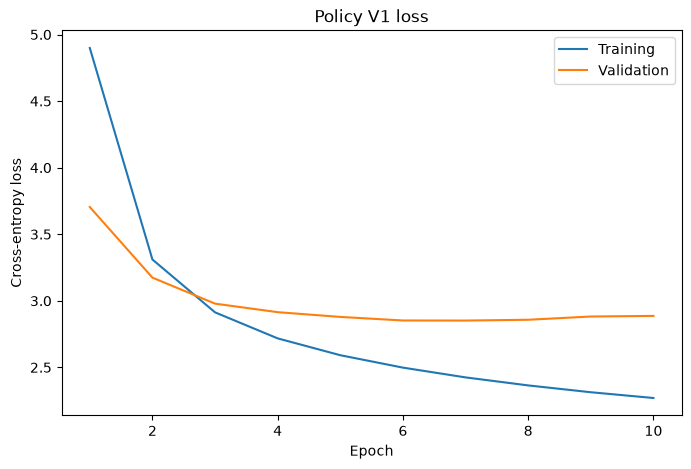

In [36]:
# 12. Loss curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Policy V1 loss")
plt.legend()
plt.show()

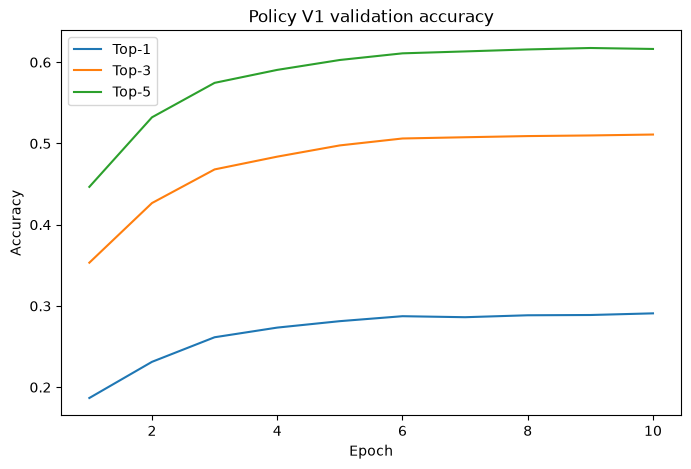

In [37]:
# 13. Validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["validation_top1"],
    label="Top-1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top3"],
    label="Top-3",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top5"],
    label="Top-5",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Policy V1 validation accuracy")
plt.legend()
plt.show()

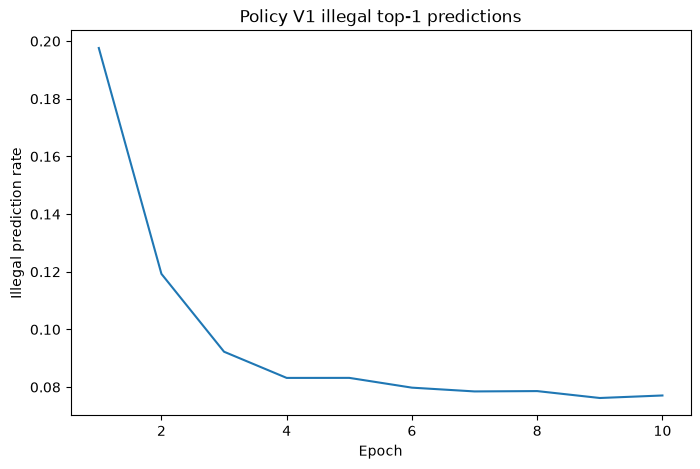

In [38]:
# 14. Illegal top-1 prediction rate

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["validation_illegal_top1"],
)

plt.xlabel("Epoch")
plt.ylabel("Illegal prediction rate")
plt.title("Policy V1 illegal top-1 predictions")
plt.show()

In [39]:
# 15. Best validation result

best_epoch = history_df.loc[
    history_df["validation_loss"].idxmin()
]

best_epoch

epoch                      7.000000
train_loss                 2.424729
train_top1                 0.345507
train_top3                 0.586933
train_top5                 0.697584
validation_loss            2.851644
validation_top1            0.286145
validation_top3            0.507663
validation_top5            0.613304
validation_illegal_top1    0.078494
Name: 6, dtype: float64

V1 Baseline

```
V1 Policy CNN
────────────────────────────────

Training games:       10,000
Minimum Elo:          1800
Split:                80/20 by game
Batch size:           256
Epochs:               10
Parameters:           6,372,832
Training time:        ~16 min

Best val loss:        2.8516 (epoch 7)

Final observed:
Top-1:                29.09%
Top-3:                51.10%
Top-5:                61.63%
Illegal top-1:         7.71%
```